# Wine Quality Prediction :

In [66]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


## 1. Loading Dataset :

In [4]:
wine_data = pd.read_csv('WineQT.csv')
wine_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [7]:
data_copy_1 = wine_data.copy()
data_copy_2 = wine_data.copy()
data_copy_3 = wine_data.copy()

## 2. Data Cleaning :

In [8]:
data_copy_1.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [9]:
data_copy_1.duplicated().sum()

np.int64(0)

## 3. EDA :

In [31]:
numeric_cols = data_copy_1.select_dtypes(['int64','float64']).columns
numeric_cols=numeric_cols.drop('Id')

In [10]:
data_copy_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [11]:
data_copy_1.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [12]:
data_copy_1.shape

(1143, 13)

## 4. Visualization :

### Histogram Representation :

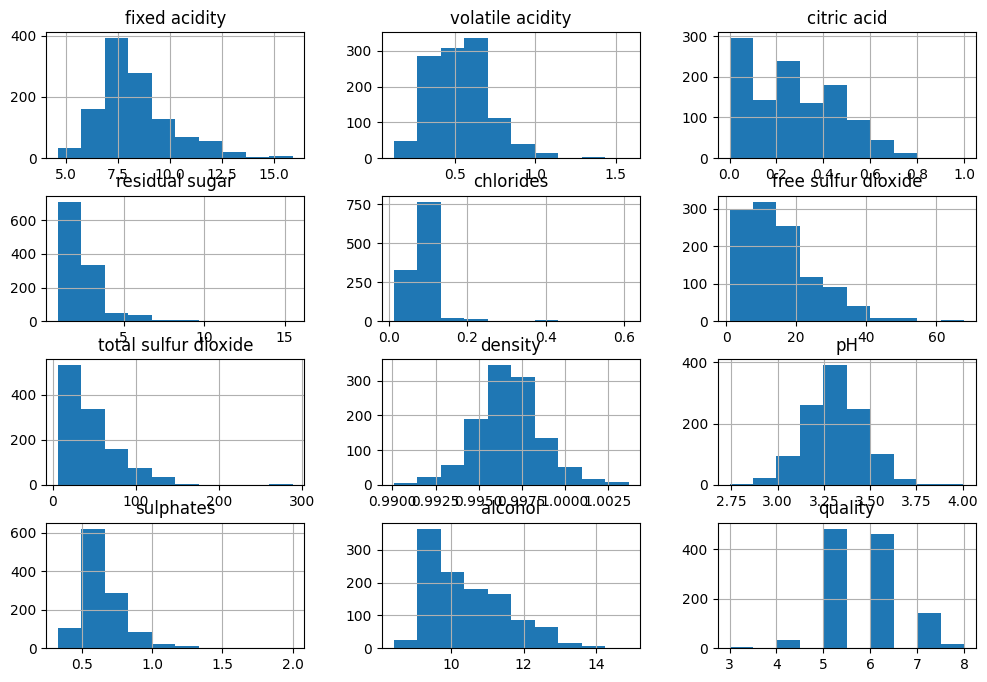

In [32]:
plt.subplots
data_copy_1[numeric_cols].hist( 
    figsize=(12,8),
    
)
plt.show()

### Outliers Detection :

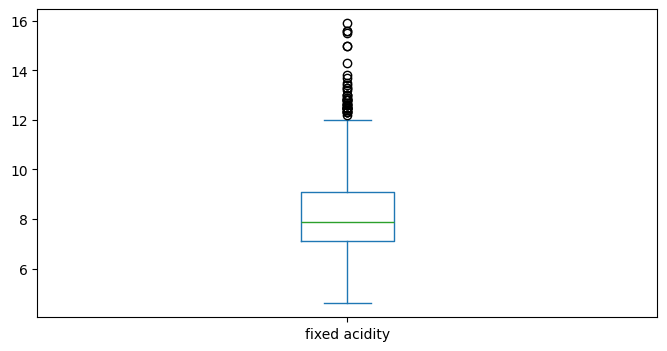

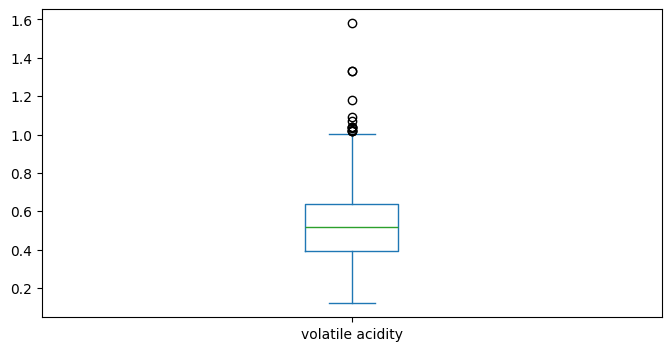

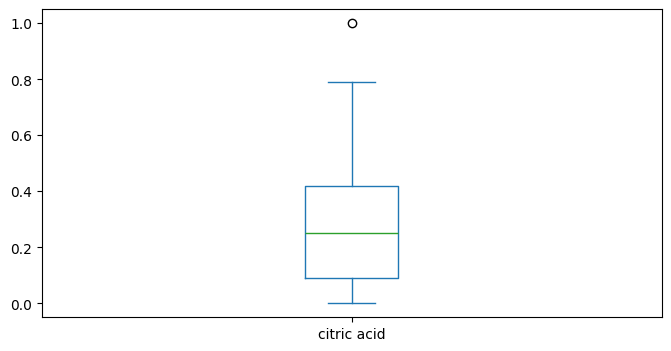

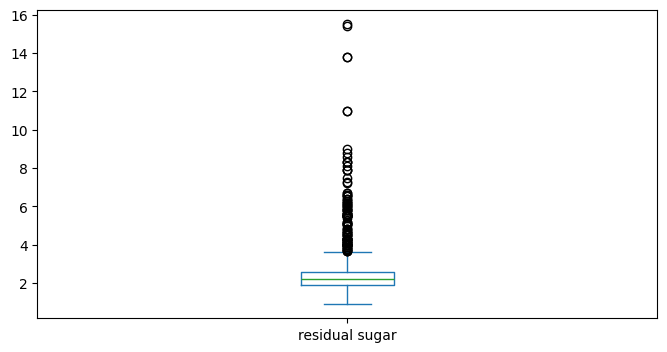

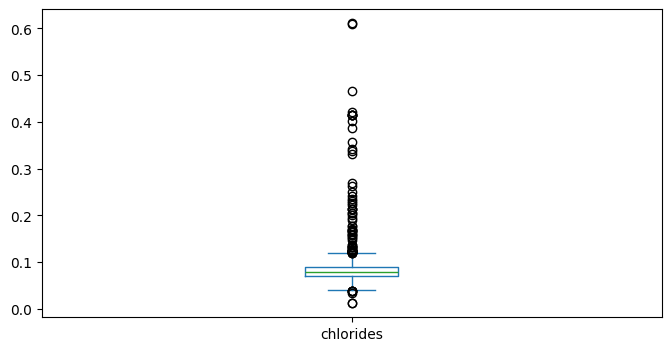

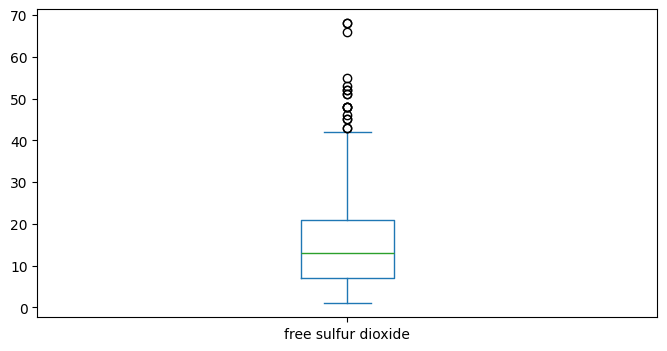

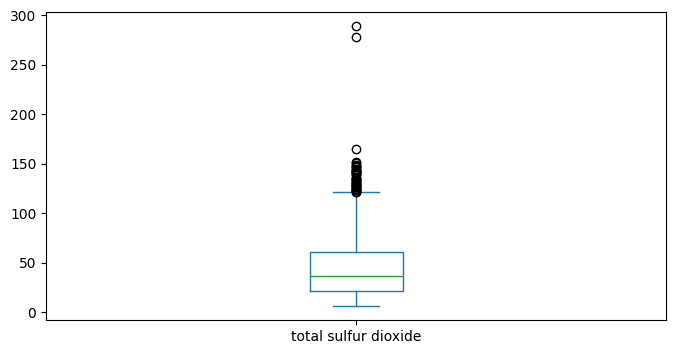

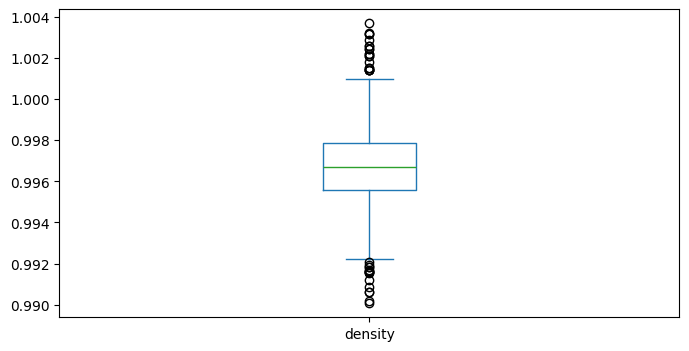

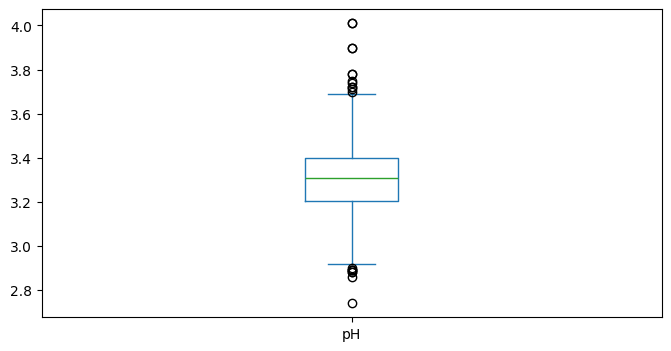

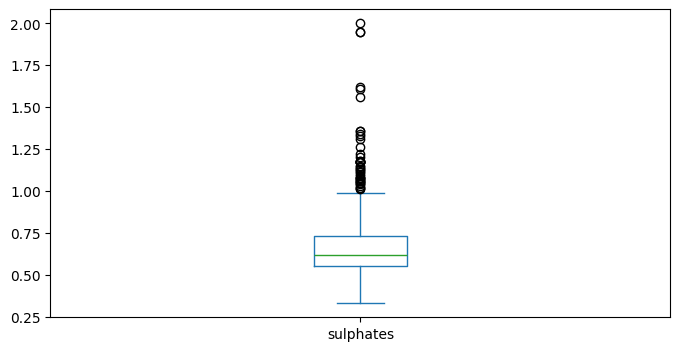

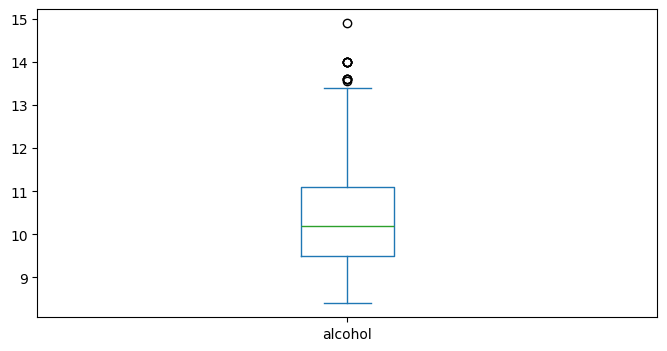

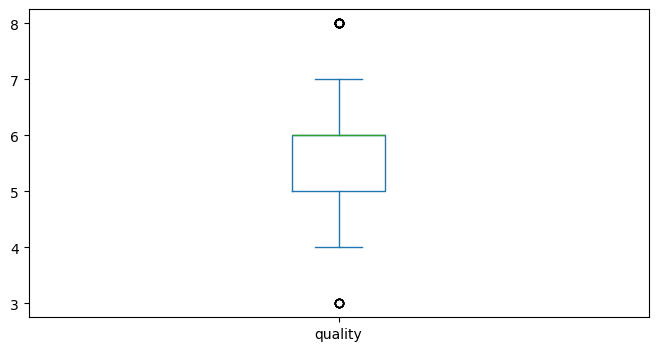

In [39]:
for col in numeric_cols:
    data_copy_1[col].plot.box(figsize=(8,4))
    plt.show()

In [41]:
for col in numeric_cols:
    Q1 = data_copy_1[col].quantile(0.25)
    Q3 = data_copy_1[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers =data_copy_1[(data_copy_1[col] < lower) | (data_copy_1[col] > upper)]
    
    print(col, "Outlier Count:", outliers.shape[0])

fixed acidity Outlier Count: 44
volatile acidity Outlier Count: 14
citric acid Outlier Count: 1
residual sugar Outlier Count: 110
chlorides Outlier Count: 77
free sulfur dioxide Outlier Count: 18
total sulfur dioxide Outlier Count: 40
density Outlier Count: 36
pH Outlier Count: 20
sulphates Outlier Count: 43
alcohol Outlier Count: 12
quality Outlier Count: 22


### Since the outlier count is very large and we have an small dataset , removing the rows result in analysis error so we can proceed with the normal dataset

## 5. Classifier Models :

In [43]:
data_copy_1 = data_copy_1.drop('Id',axis=1)

In [44]:
data_copy_1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6


## Seperating feature and target variable :

In [45]:
x = data_copy_1.drop('quality',axis = 1)
y = data_copy_1['quality']

In [49]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [51]:
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=42)

## I. Random Forest :

In [53]:
rf = RandomForestClassifier()
rf.fit(x_train , y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## II. Stochastic Gradient Descent :

In [55]:
sgd = SGDClassifier()
sgd.fit(x_train,y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


## III. Support Vector Classifier :

In [57]:
svc = SVC()
svc.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Making Predictions :

In [59]:
rf_pred = rf.predict(x_test)
sgd_pred = sgd.predict(x_test)
svc_pred = svc.predict(x_test)

## Evaluating their accuracy :

In [62]:
print('Random Forest : ',accuracy_score(y_test,rf_pred))
print('Stochastic Gradient Descent : ',accuracy_score(y_test,sgd_pred))
print('Support Vector Classifier : ',accuracy_score(y_test,svc_pred))

Random Forest :  0.7117903930131004
Stochastic Gradient Descent :  0.5851528384279476
Support Vector Classifier :  0.6375545851528385


In [64]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.73      0.81      0.77        96
           6       0.69      0.67      0.68        99
           7       0.70      0.73      0.72        26
           8       0.00      0.00      0.00         2

    accuracy                           0.71       229
   macro avg       0.43      0.44      0.43       229
weighted avg       0.69      0.71      0.70       229



C:\Users\91882\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\91882\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\91882\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Finding Important features :

<Axes: >

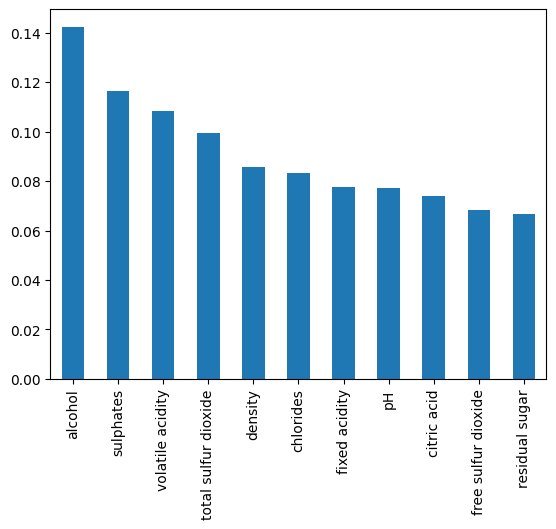

In [75]:
importance = rf.feature_importances_
pd.Series(importance, index=x.columns).sort_values(ascending=False).plot(kind='bar')

### Important features often are:

### * alcohol
### * volatile acidity
### * sulphates

## Conclusion :

### Three classification models were implemented for wine quality prediction. Among them, Random Forest achieved the highest accuracy due to its ability to handle non-linear relationships and feature interactions effectively.